# TartanRGBT Dataset Viewer

**模态**: RGB + Thermal + Depth (multi-sensor aligned)

- 5 days, 46 trajectories, indoor/outdoor/urban/offroad/park
- 同步 RGB + thermal (left/right, 8-bit/16-bit) + stereo depth
- 1 Hz 对齐, per-frame odometry + FFC flags
- 用于跨模态表示学习、thermal 感知、多传感器融合

In [1]:
import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import io

BASE = os.path.abspath(os.path.join(os.getcwd(), '..', 'dataset', 'TartanRGBT'))
DISTRIBUTION_CSV = os.path.join(BASE, 'AnyThermal_data_distribution.csv')
DAY1 = os.path.join(BASE, 'day1')

print(f'Base exists: {os.path.exists(BASE)}')
print(f'Day1 exists: {os.path.exists(DAY1)}')
print(f'Day1 trajectories:')
for d in sorted(os.listdir(DAY1)):
    if not d.startswith('.'):
        print(f'  {d}/')

Base exists: True
Day1 exists: True
Day1 trajectories:
  undistorted_images_all_cameras_20250822_115703/
  undistorted_images_all_cameras_20250822_115932/


## 1. Dataset Overview (Distribution CSV)

Total trajectories: 46

Frames per trajectory:
  10Hz: 171,825 total, mean=3735
  1Hz:  17,203 total, mean=374


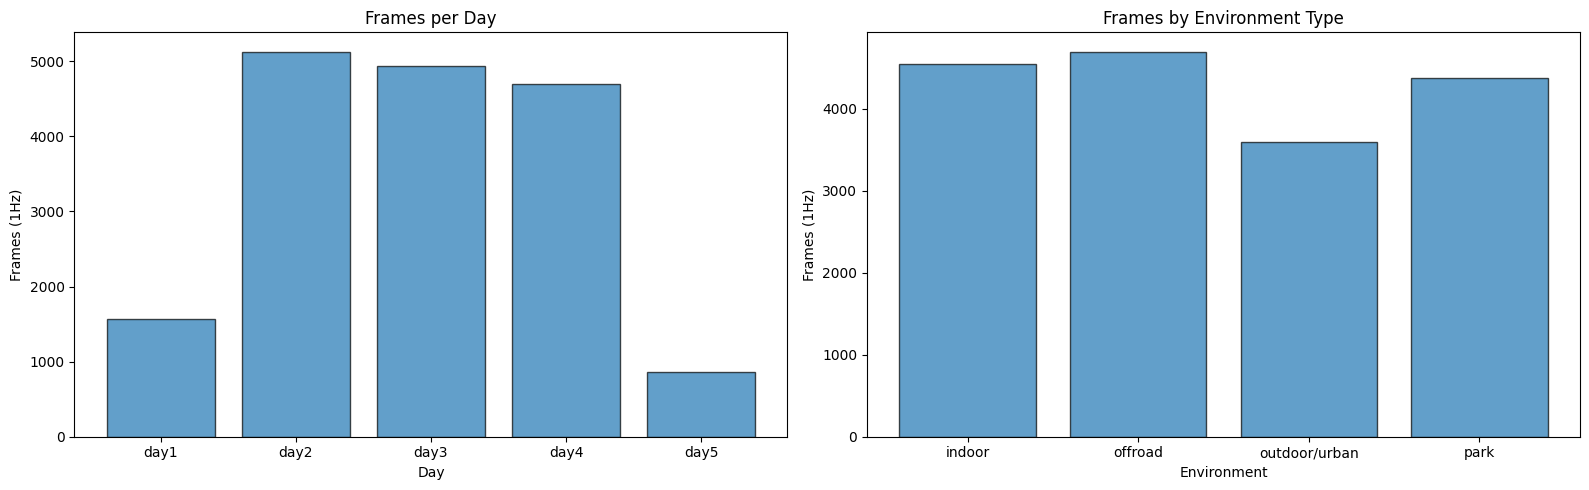

,Day,Traj,Number_10Hz,Number_1Hz,env_type
0,day1,indoor_SQH_office,1717,172,indoor
1,day1,outdoor_campus_NSH_TO_CUT,1618,162,outdoor/urban
2,day1,indoor_NSH_third_floor,2058,206,indoor
3,day1,outdoor_urban_road_campus_to_marget_morrison,2941,295,outdoor/urban
4,day1,outdoor_resedential_SQH_block,4174,418,outdoor/urban
5,day1,indoor_NSH_fourth_floor,1758,176,indoor
6,day1,indoor_NSH_first_floor,1443,145,indoor
7,day2,indoor_outdoor_mill19_building_interior_exterior,7245,725,indoor
8,day2,indoor_GATES_garage_1,1931,194,indoor
9,day2,indoor_GATES_seq_1,7096,710,indoor


In [2]:
df = pd.read_csv(DISTRIBUTION_CSV)
print(f'Total trajectories: {len(df)}')
print(f'\nFrames per trajectory:')
print(f'  10Hz: {df["Number_10Hz"].sum():,} total, mean={df["Number_10Hz"].mean():.0f}')
print(f'  1Hz:  {df["Number_1Hz"].sum():,} total, mean={df["Number_1Hz"].mean():.0f}')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

day_counts = df.groupby('Day')['Number_1Hz'].sum()
axes[0].bar(day_counts.index, day_counts.values, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Day')
axes[0].set_ylabel('Frames (1Hz)')
axes[0].set_title('Frames per Day')

env_types = []
for _, row in df.iterrows():
    traj = row['Traj']
    if 'indoor' in traj:
        env_types.append('indoor')
    elif 'outdoor' in traj or 'urban' in traj:
        env_types.append('outdoor/urban')
    elif 'park' in traj:
        env_types.append('park')
    elif 'offroad' in traj:
        env_types.append('offroad')
    else:
        env_types.append('other')
df['env_type'] = env_types
env_counts = df.groupby('env_type')['Number_1Hz'].sum()
axes[1].bar(env_counts.index, env_counts.values, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Environment')
axes[1].set_ylabel('Frames (1Hz)')
axes[1].set_title('Frames by Environment Type')
plt.tight_layout()
plt.show()

df.head(10)

## 2. Available Modalities per Trajectory

In [3]:
traj_dirs = []
for day in sorted(os.listdir(BASE)):
    day_path = os.path.join(BASE, day)
    if not os.path.isdir(day_path) or day.startswith('.'):
        continue
    for traj in sorted(os.listdir(day_path)):
        traj_path = os.path.join(day_path, traj)
        if not os.path.isdir(traj_path) or traj.startswith('.'):
            continue
        zips = [f for f in os.listdir(traj_path) if f.endswith('.zip')]
        traj_dirs.append({'day': day, 'traj': traj, 'zips': zips, 'n_zips': len(zips)})

print(f'Found {len(traj_dirs)} trajectories with ZIP files\n')
all_zips = set()
for t in traj_dirs:
    all_zips.update(t['zips'])
print(f'Unique ZIP types: {sorted(all_zips)}\n')

from collections import Counter
zip_counts = Counter()
for t in traj_dirs:
    for z in t['zips']:
        zip_counts[z] += 1
print('ZIP availability across trajectories:')
for z in sorted(zip_counts):
    print(f'  {z:35s}: {zip_counts[z]}/{len(traj_dirs)} trajectories')

Found 2 trajectories with ZIP files

Unique ZIP types: ['metadata.zip', 'rgb_in_thermal.zip', 'stereo_depth.zip', 'thermal_left_rect_8.zip', 'thermal_right_rect_16.zip', 'thermal_right_rect_8.zip', 'zed_left_rect.zip', 'zed_right_rect.zip']

ZIP availability across trajectories:
  metadata.zip                       : 2/2 trajectories
  rgb_in_thermal.zip                 : 1/2 trajectories
  stereo_depth.zip                   : 1/2 trajectories
  thermal_left_rect_8.zip            : 2/2 trajectories
  thermal_right_rect_16.zip          : 2/2 trajectories
  thermal_right_rect_8.zip           : 2/2 trajectories
  zed_left_rect.zip                  : 1/2 trajectories
  zed_right_rect.zip                 : 1/2 trajectories


## 3. Preview: RGB + Thermal + Depth (Day 1, Trajectory 1)

In [4]:
traj1_path = os.path.join(DAY1, sorted(os.listdir(DAY1))[0])
print(f'Previewing: {traj1_path}')
zips_in_traj = [f for f in os.listdir(traj1_path) if f.endswith('.zip')]
print(f'Available: {zips_in_traj}')

def list_zip_images(zip_path, max_list=20):
    with zipfile.ZipFile(zip_path, 'r') as zf:
        names = [n for n in zf.namelist() if n.lower().endswith(('.png', '.jpg', '.jpeg'))]
        print(f'  {os.path.basename(zip_path)}: {len(names)} images')
        for n in names[:max_list]:
            print(f'    {n}')
        if len(names) > max_list:
            print(f'    ... and {len(names) - max_list} more')
        return names

for z in zips_in_traj:
    zip_path = os.path.join(traj1_path, z)
    names = list_zip_images(zip_path, max_list=5)

Previewing: /home/wzk/projects/ctm_llm/dataset/TartanRGBT/day1/undistorted_images_all_cameras_20250822_115932
Available: ['zed_left_rect.zip', 'thermal_left_rect_8.zip', 'stereo_depth.zip', 'metadata.zip', 'thermal_right_rect_8.zip', 'thermal_right_rect_16.zip']
  zed_left_rect.zip: 162 images
    zed_left_rect/00000000.png
    zed_left_rect/00000010.png
    zed_left_rect/00000020.png
    zed_left_rect/00000030.png
    zed_left_rect/00000040.png
    ... and 157 more
  thermal_left_rect_8.zip: 162 images
    thermal_left_rect_8/00000000.png
    thermal_left_rect_8/00000010.png
    thermal_left_rect_8/00000020.png
    thermal_left_rect_8/00000030.png
    thermal_left_rect_8/00000040.png
    ... and 157 more
  stereo_depth.zip: 0 images
  metadata.zip: 0 images
  thermal_right_rect_8.zip: 162 images
    thermal_right_rect_8/00000000.png
    thermal_right_rect_8/00000010.png
    thermal_right_rect_8/00000020.png
    thermal_right_rect_8/00000030.png
    thermal_right_rect_8/00000040.png
  

## 4. Visualize RGB + Thermal Pairs

In [5]:
N_SHOW = 4

rgb_zip_path = os.path.join(traj1_path, 'rgb_in_thermal.zip')
thermal_zip_path = os.path.join(traj1_path, 'thermal_left_rect_8.zip')

has_rgb = os.path.exists(rgb_zip_path)
has_thermal = os.path.exists(thermal_zip_path)
print(f'RGB ZIP: {has_rgb}, Thermal ZIP: {has_thermal}')

if has_rgb and has_thermal:
    with zipfile.ZipFile(rgb_zip_path, 'r') as zf_rgb, \
         zipfile.ZipFile(thermal_zip_path, 'r') as zf_th:
        rgb_names = sorted([n for n in zf_rgb.namelist() if n.endswith('.png')])
        th_names = sorted([n for n in zf_th.namelist() if n.endswith('.png')])
        n_pairs = min(N_SHOW, len(rgb_names), len(th_names))
        indices = np.linspace(0, min(len(rgb_names), len(th_names))-1, n_pairs, dtype=int)

        fig, axes = plt.subplots(2, n_pairs, figsize=(4*n_pairs, 8))
        if n_pairs == 1:
            axes = axes.reshape(2, 1)
        for col, idx in enumerate(indices):
            rgb_data = zf_rgb.read(rgb_names[idx])
            rgb_img = Image.open(io.BytesIO(rgb_data))
            axes[0, col].imshow(rgb_img)
            axes[0, col].set_title(f'RGB #{idx}', fontsize=9)
            axes[0, col].axis('off')

            th_data = zf_th.read(th_names[idx])
            th_img = Image.open(io.BytesIO(th_data))
            axes[1, col].imshow(th_img, cmap='inferno')
            axes[1, col].set_title(f'Thermal #{idx}', fontsize=9)
            axes[1, col].axis('off')

        axes[0, 0].set_ylabel('RGB', fontsize=12)
        axes[1, 0].set_ylabel('Thermal', fontsize=12)
        plt.suptitle(f'RGB + Thermal pairs ({os.path.basename(traj1_path)})', fontsize=11)
        plt.tight_layout()
        plt.show()
        print(f'Total: {len(rgb_names)} RGB, {len(th_names)} thermal frames')

RGB ZIP: False, Thermal ZIP: True


## 5. Depth Preview (if available)

Found zed_right_rect.zip in undistorted_images_all_cameras_20250822_115703
  172 frames


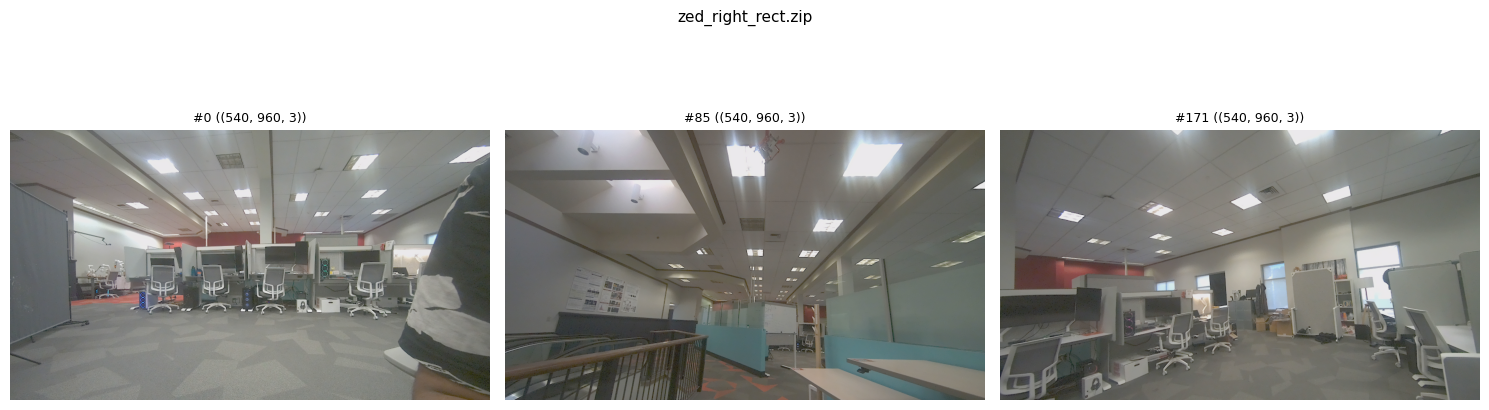

In [6]:
traj2_path = os.path.join(DAY1, sorted(os.listdir(DAY1))[1]) if len(os.listdir(DAY1)) > 1 else traj1_path

for zname in ['stereo_depth.zip', 'zed_left_rect.zip', 'zed_right_rect.zip']:
    zpath = os.path.join(traj2_path, zname)
    if not os.path.exists(zpath):
        continue
    print(f'Found {zname} in {os.path.basename(traj2_path)}')
    with zipfile.ZipFile(zpath, 'r') as zf:
        names = sorted([n for n in zf.namelist() if n.lower().endswith(('.png', '.jpg', '.jpeg'))])
        print(f'  {len(names)} frames')
        if not names:
            print(f'  Skipping (no images found)')
            continue
        indices = np.linspace(0, len(names)-1, 3, dtype=int)
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        for ax, idx in zip(axes, indices):
            data = zf.read(names[idx])
            img = Image.open(io.BytesIO(data))
            arr = np.array(img)
            if 'depth' in zname:
                im = ax.imshow(arr, cmap='turbo')
                plt.colorbar(im, ax=ax, fraction=0.046)
            else:
                ax.imshow(arr)
            ax.set_title(f'#{idx} ({arr.shape})', fontsize=9)
            ax.axis('off')
        plt.suptitle(f'{zname}', fontsize=11)
        plt.tight_layout()
        plt.show()

## 6. Metadata & Odometry

=== undistorted_images_all_cameras_20250822_115932 ===
  thermal_left_ffc/data.txt (324 bytes)
  thermal_left_ffc/errors.txt (40450 bytes)
  thermal_left_ffc/frames.yaml (13 bytes)
  thermal_left_ffc/timestamps.txt (42068 bytes)
  thermal_right_ffc/data.txt (3236 bytes)
  thermal_right_ffc/errors.txt (40450 bytes)
  thermal_right_ffc/frames.yaml (13 bytes)
  thermal_right_ffc/timestamps.txt (42068 bytes)
  thermal_left_rect_16/errors.txt (40450 bytes)
  thermal_left_rect_16/timestamps.txt (40450 bytes)
  odometry/poses.npy (67712 bytes)
  tf/metadata.yaml (355 bytes)
  tf/thermal_left-optical_frame_to_thermal_right-optical_frame/static_transform.txt (178 bytes)
  tf/zed_left_camera_optical_frame_to_zed_imu/static_transform.txt (175 bytes)
  tf/zed_left_camera_optical_frame_to_zed_right_camera_optical_frame/static_transform.txt (175 bytes)
  tf/zed_left_camera_optical_frame_to_thermal_left-optical_frame/static_transform.txt (175 bytes)
  target_timestamps.txt (4050 bytes)

  Odometry po

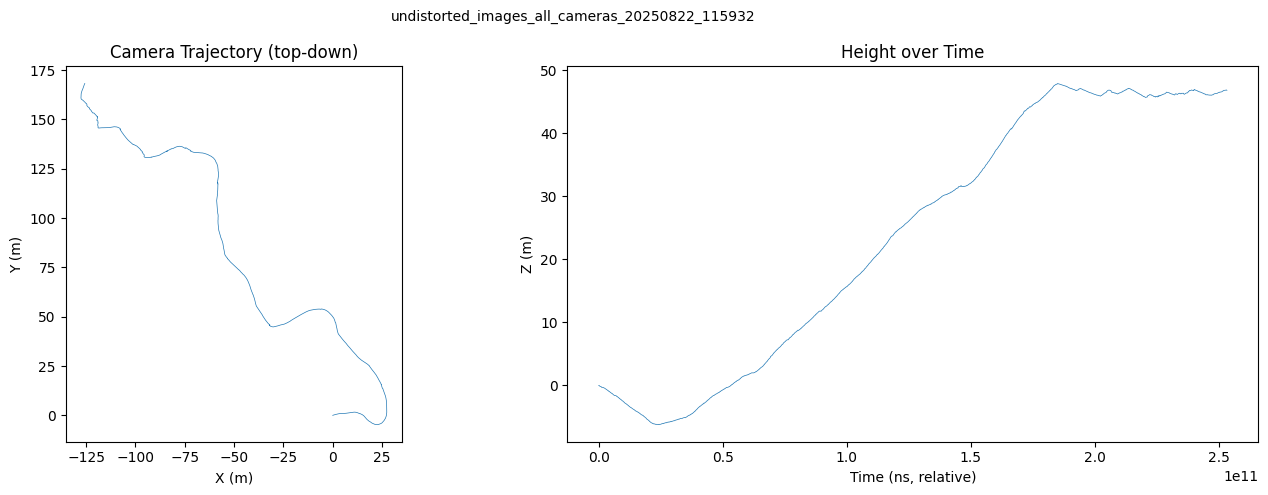

In [7]:
import tempfile

for traj_name in os.listdir(DAY1):
    traj_path = os.path.join(DAY1, traj_name)
    if not os.path.isdir(traj_path) or traj_name.startswith('.'):
        continue
    meta_zip = os.path.join(traj_path, 'metadata.zip')
    if not os.path.exists(meta_zip):
        continue
    print(f'=== {traj_name} ===')
    with zipfile.ZipFile(meta_zip, 'r') as zf:
        for name in zf.namelist():
            print(f'  {name} ({zf.getinfo(name).file_size} bytes)')

        poses_path = [n for n in zf.namelist() if n.endswith('poses.npy')]
        if poses_path:
            data = zf.read(poses_path[0])
            tmp = os.path.join(tempfile.gettempdir(), 'poses_tmp.npy')
            with open(tmp, 'wb') as f:
                f.write(data)
            poses = np.load(tmp)
            print(f'\n  Odometry poses: {poses.shape}')
            print(f'  Columns: [timestamp_ns, x, y, z, qx, qy, qz, qw]')
            print(f'  XYZ range: x=[{poses[:,1].min():.1f}, {poses[:,1].max():.1f}] '
                  f'y=[{poses[:,2].min():.1f}, {poses[:,2].max():.1f}] '
                  f'z=[{poses[:,3].min():.1f}, {poses[:,3].max():.1f}]')

            fig, axes = plt.subplots(1, 2, figsize=(14, 5))
            axes[0].plot(poses[:, 1], poses[:, 2], '-', linewidth=0.5)
            axes[0].set_xlabel('X (m)')
            axes[0].set_ylabel('Y (m)')
            axes[0].set_title('Camera Trajectory (top-down)')
            axes[0].set_aspect('equal')

            axes[1].plot(poses[:, 0] - poses[0, 0], poses[:, 3], '-', linewidth=0.5)
            axes[1].set_xlabel('Time (ns, relative)')
            axes[1].set_ylabel('Z (m)')
            axes[1].set_title('Height over Time')
            plt.suptitle(f'{traj_name}', fontsize=10)
            plt.tight_layout()
            plt.show()
        break

## 7. Cross-Modality Alignment Check

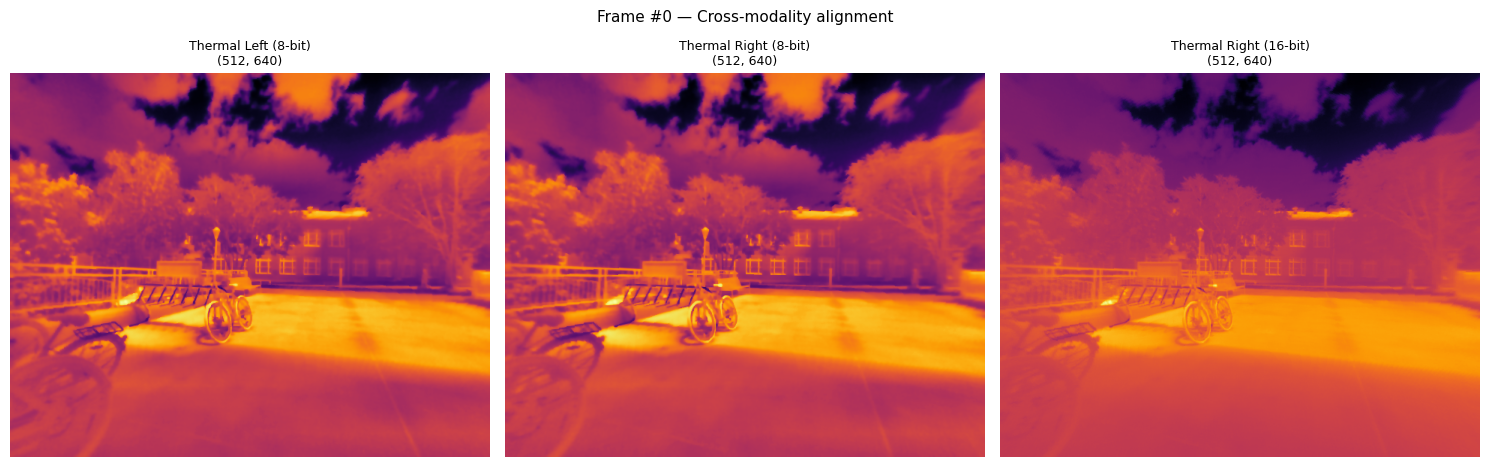

In [8]:
traj_path = os.path.join(DAY1, os.listdir(DAY1)[0])
modality_zips = {
    'RGB (aligned to thermal)': 'rgb_in_thermal.zip',
    'Thermal Left (8-bit)': 'thermal_left_rect_8.zip',
    'Thermal Right (8-bit)': 'thermal_right_rect_8.zip',
    'Thermal Right (16-bit)': 'thermal_right_rect_16.zip',
}

available = {}
for label, zname in modality_zips.items():
    zpath = os.path.join(traj_path, zname)
    if os.path.exists(zpath):
        with zipfile.ZipFile(zpath, 'r') as zf:
            names = sorted([n for n in zf.namelist() if n.endswith('.png')])
            available[label] = (zpath, names)

n_mods = len(available)
if n_mods == 0:
    print('No modalities found')
else:
    frame_idx = 0
    fig, axes = plt.subplots(1, n_mods, figsize=(5*n_mods, 5))
    if n_mods == 1:
        axes = [axes]
    for ax, (label, (zpath, names)) in zip(axes, available.items()):
        with zipfile.ZipFile(zpath, 'r') as zf:
            data = zf.read(names[frame_idx])
            img = Image.open(io.BytesIO(data))
            arr = np.array(img)
            if 'Thermal' in label:
                ax.imshow(arr, cmap='inferno')
            else:
                ax.imshow(arr)
            ax.set_title(f'{label}\n{arr.shape}', fontsize=9)
            ax.axis('off')
    plt.suptitle(f'Frame #{frame_idx} — Cross-modality alignment', fontsize=11)
    plt.tight_layout()
    plt.show()

## 8. Image Resolution Summary

In [9]:
for label, (zpath, names) in available.items():
    with zipfile.ZipFile(zpath, 'r') as zf:
        first = zf.read(names[0])
        img = Image.open(io.BytesIO(first))
        print(f'{label:30s}: {img.size[0]}x{img.size[1]}, mode={img.mode}')

Thermal Left (8-bit)          : 640x512, mode=L
Thermal Right (8-bit)         : 640x512, mode=L
Thermal Right (16-bit)        : 640x512, mode=I;16
